The below code illustrates how Ridge Regression changes coefficients and affects bias/variance/total error as the $\lambda$ value changes. NOTE: the sklearn library uses the term $\alpha$ (alpha) instead of $\lambda$ (lambda), but they are the same hyperparameter.

In [88]:
#Import and load the diabetes dataset from sklearn for testing
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Split the dataset into training and validation (we'll skip a testing set since we're not deploying)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#Standardize the training and validation sets
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [90]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

alpha_values = list(range(101)) #[0.001,0.01,0.1,1, 2, 3]

#Store Ridge and LASSO MSE values as alpha increases
ridge_error_values = []
lasso_error_values = []

#Store Ridge and LASSO coefficient values as alpha increases
ridge_coefficient_values = []
lasso_coefficient_values = []

#Vary alpha from small to large
for alpha in alpha_values:
    #Train Ridge model on the training set and predict on the validation set
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    ridge_predictions = ridge_model.predict(X_val)

    #Train LASSO model on the training set and predict on the validation set
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train, y_train)
    lasso_predictions = lasso_model.predict(X_val)

    ridge_error_values.append(mean_squared_error(ridge_predictions, y_val))
    lasso_error_values.append(mean_squared_error(lasso_predictions, y_val))
    ridge_coefficient_values.append(ridge_model.coef_) # Store Ridge coefficients
    lasso_coefficient_values.append(lasso_model.coef_) # Store Lasso coefficients

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.063e+05, tolerance: 2.145e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

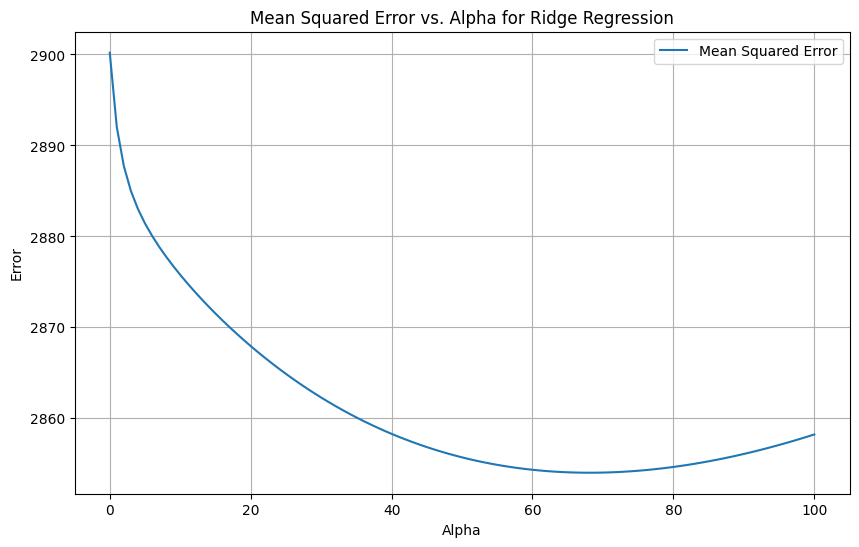

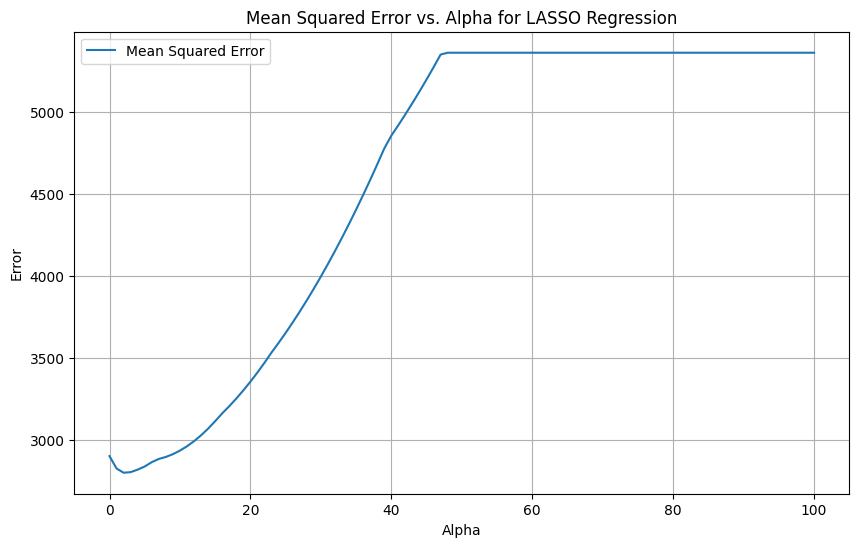

In [91]:
import matplotlib.pyplot as plt


#Plot MSE vs alpha for Ridge Regression
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, ridge_error_values, label='Mean Squared Error')

plt.xlabel('Alpha')
plt.ylabel('Error')
plt.title('Mean Squared Error vs. Alpha for Ridge Regression')
plt.legend()
plt.grid(True)
plt.show()


#Plot MSE vs alpha for LASSO Regression
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, lasso_error_values, label='Mean Squared Error')

plt.xlabel('Alpha')
plt.ylabel('Error')
plt.title('Mean Squared Error vs. Alpha for LASSO Regression')
plt.legend()
plt.grid(True)
plt.show()

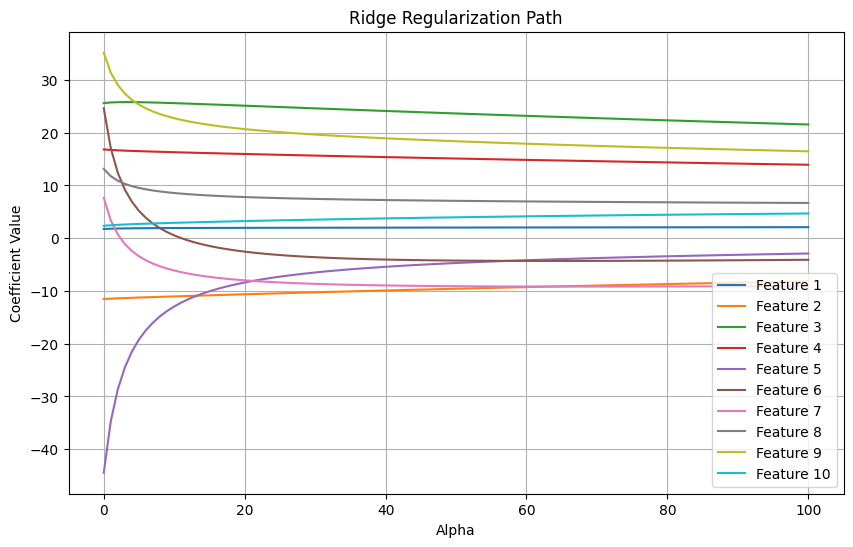

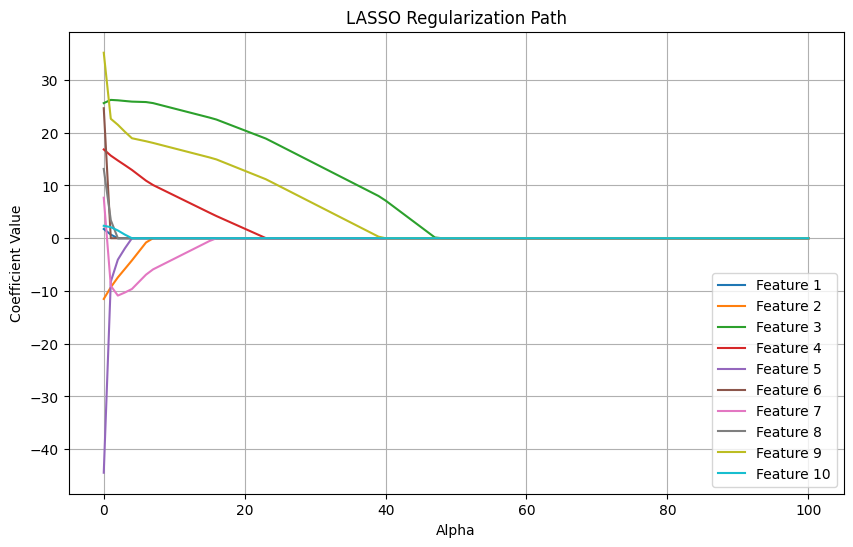

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# Plot Ridge Regularization Path
plt.figure(figsize=(10, 6))
#We transpose these values so that they are in the right order for plotting against alpha
ridge_coefficient_values_transposed = np.array(ridge_coefficient_values).T
for i in range(ridge_coefficient_values_transposed.shape[0]):
    plt.plot(alpha_values, ridge_coefficient_values_transposed[i], label=f'Feature {i+1}')

plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regularization Path')
plt.legend()
plt.grid(True)
plt.show()

# Plot Lasso Regularization Path
plt.figure(figsize=(10, 6))
lasso_coefficient_values_transposed = np.array(lasso_coefficient_values).T
for i in range(lasso_coefficient_values_transposed.shape[0]):
    plt.plot(alpha_values, lasso_coefficient_values_transposed[i], label=f'Feature {i+1}')

plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('LASSO Regularization Path')
plt.legend()
plt.grid(True)
plt.show()